# Zadanie domowe -- interpolacja dwusześcienna

Interpolacja dwusześcienna, to podobnie jak w przypadku interpolacji dwuliniowej, rozszerzenie idei interpolacji jednowymiarowej na dwuwymiarową siatkę.
W trakcie jej obliczania wykorzystywane jest 16 pikseli z otoczenia (dla dwuliniowej 4).
Skutkuje to zwykle lepszymi wynikami - obraz wyjściowy jest bardziej gładki i z mniejszą liczbą artefaktów.
Ceną jest znaczny wzrost złożoności obliczeniowej (zostało to zaobserwowane podczas ćwiczenia).

Interpolacja dana jest wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\end{equation}

Zadanie sprowadza się zatem do wyznaczenia 16 współczynników $a_{ij}$.
W tym celu wykorzystuje się, oprócz wartość w puntach $A$ (0,0), $B$ (1 0), $C$ (1,1), $D$ (0,1) (por. rysunek dotyczący interpolacji dwuliniowej), także pochodne cząstkowe $A_x$, $A_y$, $A_{xy}$.
Pozwala to rozwiązać układ 16-tu równań.

Jeśli zgrupujemy parametry $a_{ij}$:
\begin{equation}
a = [ a_{00}~a_{10}~a_{20}~a_{30}~a_{01}~a_{11}~a_{21}~a_{31}~a_{02}~a_{12}~a_{22}~a_{32}~a_{03}~a_{13}~a_{23}~a_{33}]
\end{equation}

i przyjmiemy:
\begin{equation}
x = [A~B~D~C~A_x~B_x~D_x~C_x~A_y~B_y~D_y~C_y~A_{xy}~B_{xy}~D_{xy}~C_{xy}]^T
\end{equation}

To zagadnienie można opisać w postaci równania liniowego:
\begin{equation}
Aa = x
\end{equation}
gdzie macierz $A^{-1}$ dana jest wzorem:

\begin{equation}
A^{-1} =
\begin{bmatrix}
1& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0 \\
0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
-3&  3&  0&  0& -2& -1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
2& -2&  0&  0&  1&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0& -3&  3&  0&  0& -2& -1&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  2& -2&  0&  0&  1&  1&  0&  0 \\
-3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0& -3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0 \\
9& -9& -9&  9&  6&  3& -6& -3&  6& -6&  3& -3&  4&  2&  2&  1 \\
-6&  6&  6& -6& -3& -3&  3&  3& -4&  4& -2&  2& -2& -2& -1& -1 \\
2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0 \\
-6&  6&  6& -6& -4& -2&  4&  2& -3&  3& -3&  3& -2& -1& -2& -1 \\
4& -4& -4&  4&  2&  2& -2& -2&  2& -2&  2& -2&  1&  1&  1&  1 \\
\end{bmatrix}
\end{equation}

Potrzebne w rozważaniach pochodne cząstkowe obliczane są wg. następującego przybliżenia (przykład dla punktu A):
\begin{equation}
A_x = \frac{I(i+1,j) - I(i-1,j)}{2}
\end{equation}

\begin{equation}
A_y = \frac{I(i,j+1) - I(i,j-1)}{2}
\end{equation}

\begin{equation}
A_{xy} = \frac{I(i+1,j+1) - I(i-1,j) - I(i,j-1) + I(i,j)}{4}
\end{equation}

## Zadanie

Wykorzystując podane informacje zaimplementuj interpolację dwusześcienną.
Uwagi:
- macierz $A^{-1}$ dostępna jest w pliku *a_invert.py*
- trzeba się zastanowić nad potencjalnym wykraczaniem poza zakres obrazka (jak zwykle).

Ponadto dokonaj porównania liczby operacji arytmetycznych i dostępów do pamięci koniecznych przy realizacji obu metod interpolacji: dwuliniowej i dwusześciennej.

In [1]:
import os

import cv2
import numpy as np
import requests
from matplotlib import pyplot as plt

from ainvert import A_invert

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/"

fileName = "ainvert.py"
if not os.path.exists(fileName):
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, "wb").write(r.content)

fileNames = ["parrot.bmp", "clock.bmp", "chessboard.bmp", "firetruck.jpg", "lena.bmp"]
for fileName in fileNames:
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, "wb").write(r.content)

images = {}
images["parrot"] = cv2.imread("parrot.bmp", cv2.IMREAD_GRAYSCALE)
images["clock"] = cv2.imread("clock.bmp", cv2.IMREAD_GRAYSCALE)
images["chessboard"] = cv2.imread("chessboard.bmp", cv2.IMREAD_GRAYSCALE)
images["firetruck"] = cv2.imread("firetruck.jpg", cv2.IMREAD_GRAYSCALE)
images["lena"] = cv2.imread("lena.bmp", cv2.IMREAD_GRAYSCALE)

In [2]:
def show_image(image, dpi=200, title=""):
    plt.figure(figsize=(image.shape[0] / 100, image.shape[1] / 100), dpi=dpi)
    plt.imshow(image, cmap="gray")
    plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
    if title:
        plt.title(title)
    plt.show()

In [3]:
def bilinear_interpolation(image, *, x_scale=1, y_scale=1):
    X, Y = image.shape
    X_scaled = int(X * x_scale)
    Y_scaled = int(Y * y_scale)

    output = np.zeros((X_scaled, Y_scaled), dtype=np.uint8)

    for i in range(X_scaled):
        for j in range(Y_scaled):
            x_in = i / x_scale
            y_in = j / y_scale

            i1 = int(x_in)
            i2 = min(i1 + 1, X - 1)
            dx = x_in - i1

            j1 = int(y_in)
            j2 = min(j1 + 1, Y - 1)
            dy = y_in - j1

            fA = image[i1, j1]
            fB = image[i2, j1]
            fC = image[i2, j2]
            fD = image[i1, j2]

            fAB = fA * (1 - dx) + fB * dx
            fCD = fD * (1 - dx) + fC * dx
            output[i, j] = fAB * (1 - dy) + fCD * dy

    return output

In [4]:
def cubic_interpolation(image, *, x_scale=1, y_scale=1, A_inv=A_invert):
    X, Y = image.shape
    X_scaled = int(X * x_scale)
    Y_scaled = int(Y * y_scale)

    output = np.zeros((X_scaled, Y_scaled), dtype=np.uint8)

    def get_derivatives(i, j):
        i_next = min(i + 1, X - 1)
        i_prev = max(i - 1, 0)
        j_next = min(j + 1, Y - 1)
        j_prev = max(j - 1, 0)

        dx = (int(image[i_next, j]) - int(image[i_prev, j])) / 2

        dy = (int(image[i, j_next]) - int(image[i, j_prev])) / 2

        dxy = (
            int(image[i_next, j_next])
            - int(image[i_prev, j])
            - int(image[i, j_prev])
            + int(image[i, j]) / 4
        )

        return dx, dy, dxy

    for i in range(X_scaled):
        for j in range(Y_scaled):
            x_in = i / x_scale
            y_in = j / y_scale

            # base coordinates
            i1 = int(x_in)
            j1 = int(y_in)
            i2 = min(i1 + 1, X - 1)
            j2 = min(j1 + 1, Y - 1)

            # local coordinates
            x = x_in - i1
            y = y_in - j1

            A = int(image[i1, j1])
            B = int(image[i2, j1])
            C = int(image[i2, j2])
            D = int(image[i1, j2])

            # derivatives at corners
            A_x, A_y, A_xy = get_derivatives(i1, j1)
            B_x, B_y, B_xy = get_derivatives(i2, j1)
            C_x, C_y, C_xy = get_derivatives(i2, j2)
            D_x, D_y, D_xy = get_derivatives(i1, j2)

            x_vec = np.block(
                [
                    A,
                    B,
                    D,
                    C,
                    A_x,
                    B_x,
                    D_x,
                    C_x,
                    A_y,
                    B_y,
                    D_y,
                    C_y,
                    A_xy,
                    B_xy,
                    D_xy,
                    C_xy,
                ]
            )

            a = A_inv @ x_vec

            # bicubic polynomial
            result = 0
            for m in range(4):
                for n in range(4):
                    result += a[m + 4 * n] * (x**m) * (y**n)

            output[i, j] = np.clip(result, 0, 255)

    return output

In [5]:
from timeit import default_timer as timer


def measure_interpolation_time(image, x_scale, y_scale, interpolation, dpi=100):
    start = timer()
    output = interpolation(image, x_scale=x_scale, y_scale=y_scale)
    end = timer()

    interpolation_methods = {
        bilinear_interpolation: "bilinear",
        cubic_interpolation: "cubic",
    }
    interpolation_name = interpolation_methods[interpolation]

    show_image(
        output,
        title=f"{interpolation_name.title()} \n{x_scale}x{y_scale} \n({(end - start)*1000:.2f}ms)",
        dpi=dpi,
    )

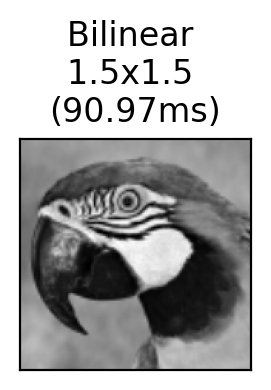

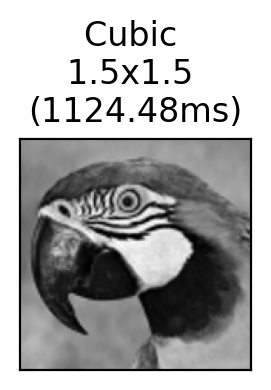

In [6]:
measure_interpolation_time(images["parrot"], 1.5, 1.5, bilinear_interpolation, dpi=200)
measure_interpolation_time(images["parrot"], 1.5, 1.5, cubic_interpolation, dpi=200)

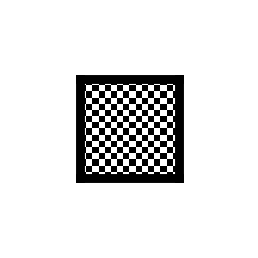

In [7]:
show_image(images["chessboard"], dpi=800)

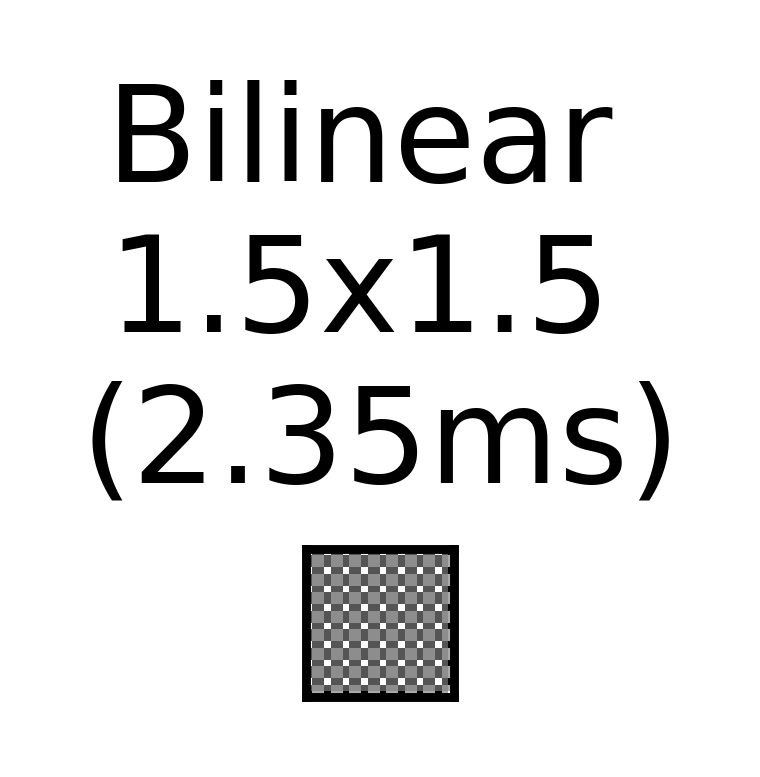

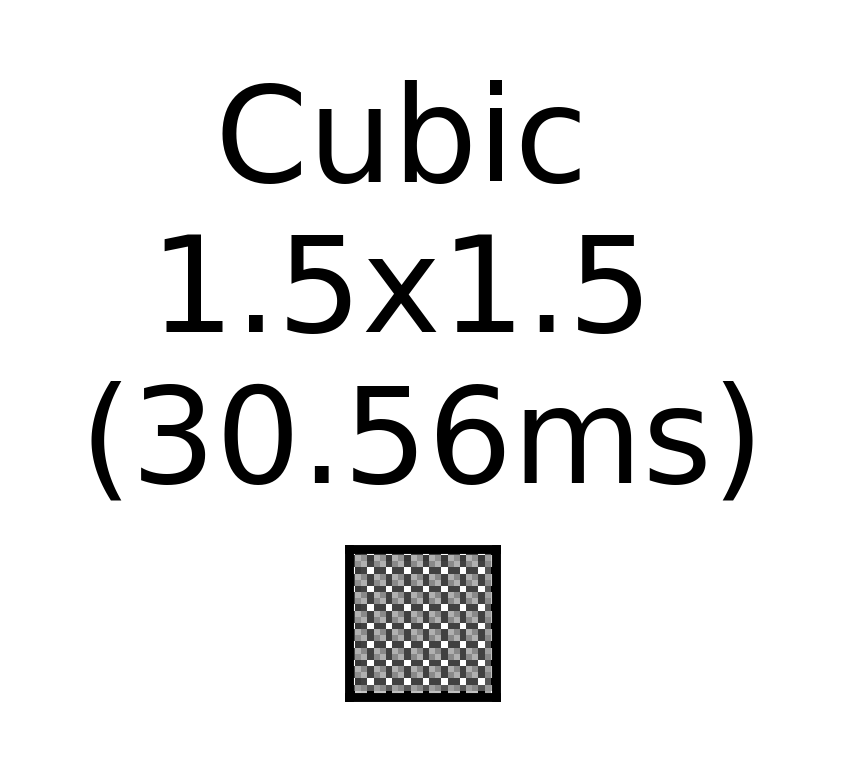

In [8]:
measure_interpolation_time(images["chessboard"], 1.5, 1.5, bilinear_interpolation, dpi=800)
measure_interpolation_time(images["chessboard"], 1.5, 1.5, cubic_interpolation, dpi=800)

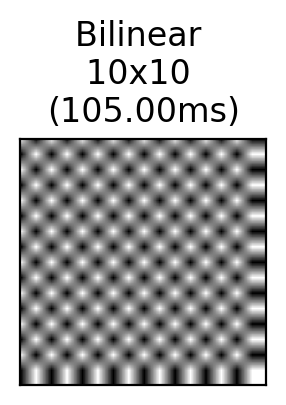

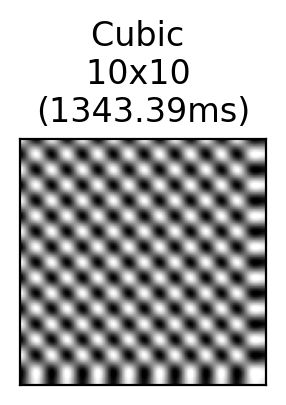

In [9]:
measure_interpolation_time(images["chessboard"], 10, 10, bilinear_interpolation, dpi=200)
measure_interpolation_time(images["chessboard"], 10, 10, cubic_interpolation, dpi=200)